# Exercício Prático 2: Sistema Especialista

Disciplina: Inteligência Artificial


Período: 2026.1

Nomes: Pedro Henrique de Oliveira Duarte, Rodrigo Girão Motta

Matrículas: 20240014296, XXXXXXXXXXX

Problema: predizer a classe de aceitação de um veículo a partir de características categóricas como preço de compra, custo de manutenção, número de portas, capacidade de passageiros, tamanho do porta-malas e segurança.

Link do dataset: foi utilizado o dataset Car Evaluation, disponível em: https://archive.ics.uci.edu/dataset/19/car+evaluation

Resumo: o dataset Car Evaluation classifica veículos em quatro classes (unacc, acc, good e vgood) com base em critérios discretos. Por isso, ele é adequado para um sistema especialista, já que as decisões podem ser representadas como regras condicionais.

Abordagem: foi treinada uma árvore de decisão com profundidade máxima 3, as categorias foram mapeadas com OrdinalEncoder. A escolha da árvore foi feita porque o modelo gera caminhos de decisão com possibilidade de tradução para Prolog. A avaliação usa holdout aleatório, separando 80% dos dados para treino e 20% para teste. Ao final, os principais caminhos da árvore são convertidos em uma base de conhecimento Prolog.

### 0. Instalação de dependências

- Biblioteca **numpy**: matemática e álgebra linear com vetores e matrizes
- Biblioteca **pandas**: análise e manipulação de dados tabulares
- Biblioteca **scikit-learn**: caixa de ferramentas para aprendizado de máquina
- Biblioteca **matplotlib**: visualização de dados
- Biblioteca **pyswip**: integração entre Python e Prolog
- **SWI-Prolog**: dependência nativa necessária para o PySwip executar consultas Prolog

In [4]:
%pip install numpy pandas scikit-learn matplotlib pyswip

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Coleta de dados

In [5]:
import pandas as pd

from sklearn.datasets import fetch_openml

car = fetch_openml("car", version=3, as_frame=True)

In [6]:
print(car.DESCR[:1000])
print(car.frame.head())

**Author**: Marko Bohanec, Blaz Zupan  
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/car+evaluation) - 1997   
**Please cite**: [UCI](http://archive.ics.uci.edu/ml/citation_policy.html)  

**Car Evaluation Database**  
This database was derived from a simple hierarchical decision model originally developed for the demonstration of DEX (M. Bohanec, V. Rajkovic: Expert system for decision making. Sistemica 1(1), pp. 145-157, 1990.).

The model evaluates cars according to the following concept structure:
 
    CAR                      car acceptability
    . PRICE                  overall price
    . . buying               buying price
    . . maint                price of the maintenance
    . TECH                   technical characteristics
    . . COMFORT              comfort
    . . . doors              number of doors
    . . . persons            capacity in terms of persons to carry
    . . . lug_boot           the size of luggage boot
    . . safety               estim

In [7]:
df = car.frame

print("Dataset shape:", df.shape)

# Mostra as primeiras linhas
df.head()

Dataset shape: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [8]:
df

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


In [9]:
df.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,high,high,2,2,big,high,unacc
freq,432,432,432,576,576,576,1210


### 2. Pré-processamento

In [10]:
# Separa o dataset em X e y (X e f(X))
y = df["class"]
X = df.drop("class", axis=1)

### 3. Seleção de modelo

In [11]:
from sklearn.preprocessing import OrdinalEncoder


# OrdinalEncoder para transformar cada categoria em um número
# facilita a tradução para Prolog
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

Exibe o mapeamento feito no OrdinalEncoder, mostrando qual categoria foi convertida para cada valor. (Facilitar Prolog)

In [12]:
for feature, categories in zip(X.columns, encoder.categories_):
    print(feature, list(categories))

buying ['high', 'low', 'med', 'vhigh']
maint ['high', 'low', 'med', 'vhigh']
doors ['2', '3', '4', '5more']
persons ['2', '4', 'more']
lug_boot ['big', 'med', 'small']
safety ['high', 'low', 'med']


In [13]:
from sklearn.model_selection import train_test_split

# 80% dos exemplos são para treinamento e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
print("Dataset splits:")
print()
print("X for train:", X_train.shape)
print("y for train:", y_train.shape)
print()
print("X for test:", X_test.shape)
print("y for test:", y_test.shape)

Dataset splits:

X for train: (1382, 6)
y for train: (1382,)

X for test: (346, 6)
y for test: (346,)


### 4. Árvore de Decisão e Treino do Modelo

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

# profundidade máxima 3
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

# treinamento do modelo
model.fit(X_train, y_train)

test_preds = model.predict(X_test)

#### 4.1 Métricas calculadas manualmente
- **VP**
- **FP**
- **FN**
- **Precisão**
- **Recall**
- **F1-score**

In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

labels = model.classes_

# matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=labels)

manual_metrics = []

# calcula precisão, recall e F1 score manualmente
for index, label in enumerate(labels):
    tp = cm[index, index]
    fp = cm[:, index].sum() - tp
    fn = cm[index, :].sum() - tp
    support = cm[index, :].sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score_manual = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    manual_metrics.append({
        "classe": label,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "suporte": support,
        "precisao": precision,
        "recall": recall,
        "f1": f1_score_manual,
    })

metrics_df = pd.DataFrame(manual_metrics)
metrics_df[["precisao", "recall", "f1"]] = metrics_df[["precisao", "recall", "f1"]].round(4)

print("Métricas calculadas manualmente a partir da matriz de confusão:")
display(metrics_df)
print("\n")

print("Média macro das métricas:")
print(metrics_df[["precisao", "recall", "f1"]].mean().round(4))
print("\n")

print("Matriz de confusão:")
print(cm)


Métricas calculadas manualmente a partir da matriz de confusão:


,classe,TP,FP,FN,suporte,precisao,recall,f1
0,acc,29,29,54,83,0.5000,0.3494,0.4113
1,good,0,0,11,11,0.0000,0.0000,0.0000
2,unacc,228,60,7,235,0.7917,0.9702,0.8719
3,vgood,0,0,17,17,0.0000,0.0000,0.0000




Média macro das métricas:
precisao    0.3229
recall      0.3299
f1          0.3208
dtype: float64


Matriz de confusão:
[[ 29   0  54   0]
 [  5   0   6   0]
 [  7   0 228   0]
 [ 17   0   0   0]]


In [17]:
y_pred = model.predict(X_test)

In [18]:
y_pred

array(['unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'acc', 'acc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'acc', 'unacc', 'unacc', 'unacc', 'acc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'acc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc',
       'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'acc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc',
       'unacc', 'unacc', 'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'acc',
       'acc', 'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc'

### 5. Avaliação

Nesta etapa, a árvore treinada foi avaliada usando apenas o conjunto de teste. Assim, a avaliação indica se a árvore conseguiu aprender as regras do problema ou se decorou os exemplos de treino (overfitting)

#### 5.1 Desempenho observado nas métricas

**Alterar

### 6. Matriz de Confusão

Classes: ['acc' 'good' 'unacc' 'vgood']

Matriz de Confusão:
[[ 29   0  54   0]
 [  5   0   6   0]
 [  7   0 228   0]
 [ 17   0   0   0]]


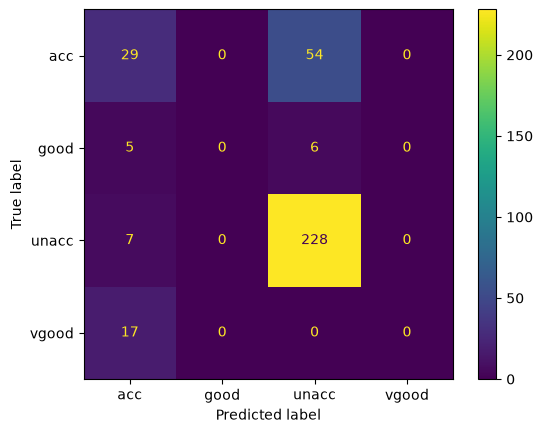

In [20]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

y_pred = model.predict(X_test)
labels = model.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Classes:", labels)
print("\nMatriz de Confusão:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()

### 7. Imprimir a árvore de decisão

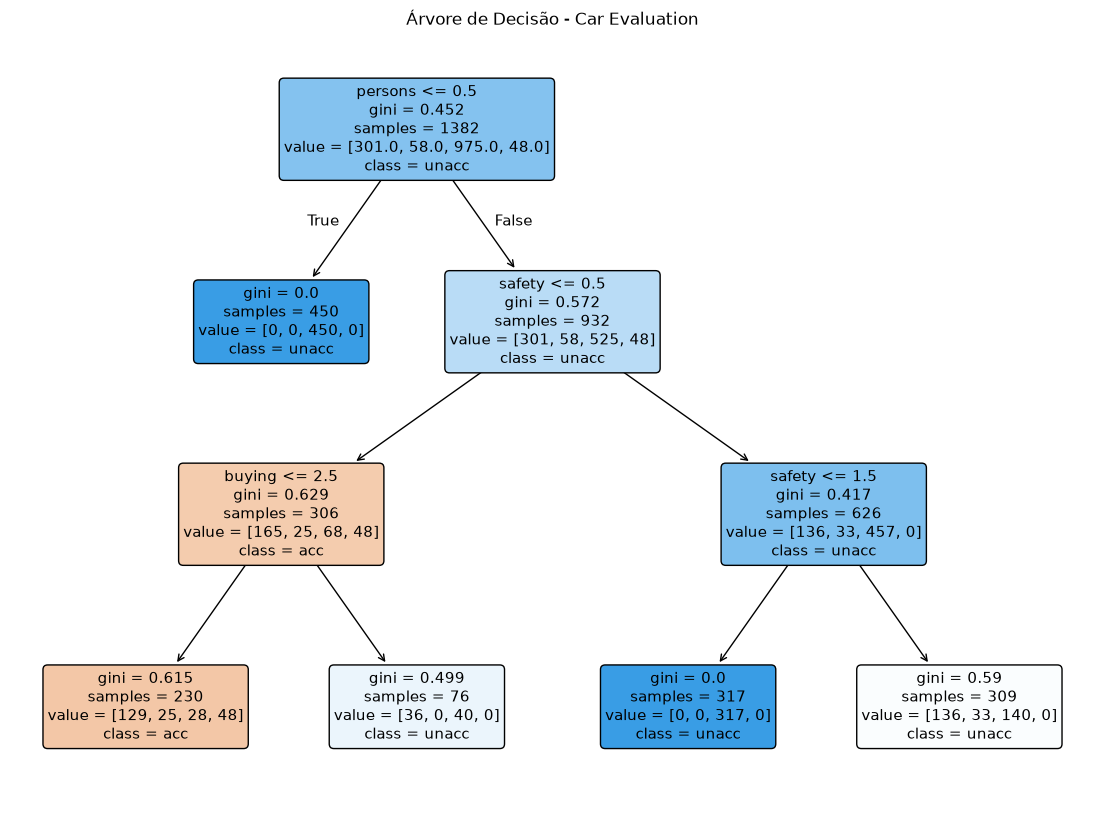

In [21]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(c) for c in model.classes_],
    filled=True,
    rounded=True
)

plt.title("Árvore de Decisão - Car Evaluation")
plt.show()

### 8. Análise dos resultados

A árvore de decisão conseguiu aprender regrasdo problema de avaliação de carros, principalmente relacionadas à quantidade de pessoas que o veículo comporta e ao nível de segurança, e tende a classificar como inaceitável(classificação predominante).

Pela matriz de confusão, a classe **unacc** foi a melhor reconhecida pelo modelo. Isso acontece porque ela é a classe com maior quantidade de exemplos no dataset, então a árvore teve mais casos desse tipo para aprender.

As classes **good** e **vgood** tiveram desempenho pior. No teste apresentado, a árvore praticamente não conseguiu prever essas classes. Isso indica que com profundidade máxima igual a 3, a árvore ficou simples demais para separar corretamente classes mais específicas. Essas classes dependem de combinações mais detalhadas entre preço de compra, manutenção, porta-malas, segurança e capacidade. Como a árvore foi limitada para ficar interpretável e facilitar a tradução para Prolog, ela não conseguiu representar todas essas combinações.

Dessa forma, houve um pouco de **underfitting**, o modelo ficou simples e generalizou demais, classificando muitos casos como **unacc** ou **acc**. Por outro lado, essa escolha também evita uma árvore muito grande. Nesse contexto, é aceitável pois o objetivo também é gerar regras e traduzi-las para uma base de conhecimento.

As características do dataset são boas para uma árvore de decisão porque são todas categóricas e representam diretamente critérios usados para avaliar um carro: preço de compra, custo de manutenção, número de portas, capacidade de pessoas, tamanho do porta-malas e segurança. A dificuldade do problema está no fato de algumas classes serem menos frequentes e dependerem de combinações mais específicas. Uma árvore mais profunda provavelmente melhoraria o desempenho em **good** e **vgood**.

Em resumo, o modelo aprendeu regras coerentes com o problema, mas a limitação de profundidade reduziu sua capacidade de distinguir todas as classes. A avaliação mostra que a árvore funciona como sistema especialista **simples**, principalmente para identificar carros inaceitáveis, mas ainda teria espaço para melhorar caso o objetivo fosse maximizar o desempenho preditivo.

### 9. Prolog

### Base de Conhecimento em Prolog

Base traduzida da árvore de decisão aprendida (`max_depth=3`).  
Cada caminho da raiz até uma folha corresponde a uma regra.  
Assinatura: `classificar(Buying, Maint, Doors, Persons, LugBoot, Safety, Classe)`

```prolog
% =============================================================
% Base de Conhecimento — Car Evaluation
% Traduzida da árvore de decisão (DecisionTreeClassifier, max_depth=3)
%
% Mapeamento de categorias (OrdinalEncoder, ordem alfabética):
%   buying  : high, low, med, vhigh
%   maint   : high, low, med, vhigh
%   doors   : '2', '3', '4', '5more'
%   persons : '2', '4', more
%   lug_boot: big, med, small
%   safety  : high, low, med
% =============================================================

% Caminho 1: persons = '2'  →  unacc
classificar(_, _, _, '2', _, _, unacc).

% Caminho 2: persons ∈ {'4', more}, safety = high, buying ∈ {high, low, med}  →  acc
classificar(Buying, _, _, Persons, _, high, acc) :-
    member(Persons, ['4', more]),
    member(Buying, [high, low, med]).

% Caminho 3: persons ∈ {'4', more}, safety = high, buying = vhigh  →  unacc
classificar(vhigh, _, _, Persons, _, high, unacc) :-
    member(Persons, ['4', more]).

% Caminho 4: persons ∈ {'4', more}, safety = low  →  unacc
classificar(_, _, _, Persons, _, low, unacc) :-
    member(Persons, ['4', more]).

% Caminho 5: persons ∈ {'4', more}, safety = med  →  unacc
classificar(_, _, _, Persons, _, med, unacc) :-
    member(Persons, ['4', more]).
```

### 10. Exemplos - Prolog

In [ ]:
import numpy as np
from pyswip import Prolog

# Carrega a base de conhecimento via PySwip
prolog = Prolog()

# Caminho 1: persons = '2' -> unacc
prolog.assertz("classificar(_,_,_,'2',_,_,unacc)")

# Caminho 2: persons em {4, more}, safety = high, buying em {high, low, med} -> acc
prolog.assertz("classificar(Buying,_,_,Persons,_,high,acc) :- member(Persons,['4',more]), member(Buying,[high,low,med])")

# Caminho 3: persons em {4, more}, safety = high, buying = vhigh -> unacc
prolog.assertz("classificar(vhigh,_,_,Persons,_,high,unacc) :- member(Persons,['4',more])")

# Caminho 4: persons em {4, more}, safety = low -> unacc
prolog.assertz("classificar(_,_,_,Persons,_,low,unacc) :- member(Persons,['4',more])")

# Caminho 5: persons em {4, more}, safety = med -> unacc
prolog.assertz("classificar(_,_,_,Persons,_,med,unacc) :- member(Persons,['4',more])")

# Seleciona 5 exemplos aleatorios do conjunto de teste
rng = np.random.default_rng(seed=7)
sample_idxs = rng.choice(len(X_test), size=5, replace=False)
sample_preds = model.predict(X_test[sample_idxs])
feature_names = list(X.columns)

def to_prolog_atom(val):
    """Atomo Prolog: aspas simples para valores que comecam com digito."""
    if val[0].isdigit():
        return f"'{val}'"
    return val

print("=" * 72)
print("  5 exemplos aleatorios - classificacao via PySwip")
print("=" * 72)

for i, (idx, sklearn_pred) in enumerate(zip(sample_idxs, sample_preds), 1):
    row_enc = X_test[idx]
    decoded = {
        feat: encoder.categories_[j][int(row_enc[j])]
        for j, feat in enumerate(feature_names)
    }

    buying = decoded["buying"]
    maint = decoded["maint"]
    doors = decoded["doors"]
    persons = decoded["persons"]
    lug_boot = decoded["lug_boot"]
    safety = decoded["safety"]

    atoms = [to_prolog_atom(decoded[f]) for f in feature_names]
    query = f"classificar({','.join(atoms)},Y)"

    results = list(prolog.query(query))
    prolog_pred = str(results[0]["Y"]) if results else "sem_resposta"

    # Verifica se as respostas coincidem
    match = "Coincidem" if sklearn_pred == prolog_pred else "Divergem"

    print(f"\nExemplo {i}:")
    print(f"  buying={buying}, maint={maint}, doors={doors}, "
        f"persons={persons}, lug_boot={lug_boot}, safety={safety}")
    print(f"  Query  : ?- {query}.")
    print(f"  Y = {prolog_pred}.")
    print(f"  sklearn: {sklearn_pred:<8}  Prolog: {prolog_pred:<8}  ->  {match}")

print("\n" + "=" * 72)

SwiPrologNotFoundError: SWI-Prolog not found